# Clean Data

In [ ]:
import pandas as pd
import numpy as np

# 1. Đọc dữ liệu (Thay tên file thực tế của bạn vào đây nếu cần)
df = pd.read_csv(
    r"\Data\vietnam-health.csv"
)  # Ở đây tôi dùng tên file 10 mẫu bạn gửi để demo

print("Số lượng dòng và cột ban đầu:", df.shape)

# 2. XÁC ĐỊNH BIẾN MỤC TIÊU (TARGET - Y)
# Gom nhóm RecPerExam thành bài toán phân loại nhị phân (Binary Classification)
# 1 = Nhóm Nguy cơ (Lười khám), 0 = Nhóm An toàn (Chăm khám)
target_mapping = {"less12": 0, "b1224": 0, "g24": 1, "unknow": 1}
df["Target_Risk"] = df["RecPerExam"].map(target_mapping)

# Lọc bỏ những dòng bị thiếu Target (nếu có)
df = df.dropna(subset=["Target_Risk"])
df["Target_Risk"] = df["Target_Risk"].astype(int)

# 3. LỰA CHỌN ĐẶC TRƯNG (FEATURE SELECTION)
# Loại bỏ các cột định danh (id, date), các biến dễ gây rò rỉ dữ liệu (RecExam, ReaExam)
# và các biến không cần thiết (height, weight, place) vì đã có BMI.
cols_to_drop = [
    "id",
    "date",
    "height",
    "weight",
    "place",
    "RecExam",
    "ReaExam",
    "RecPerExam",
]
df_ml = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

# 4. MÃ HÓA CÁC BIẾN (ENCODING)

# 4.1. Label Encoding (Biến có thứ bậc - Ordinal)
map_edu = {"Hi": 0, "Second": 1, "Grad": 2, "PostGrad": 3}
map_suitfreq = {"6m": 0, "12m": 1, "18m": 2, "g18m": 3}
map_affcost = {"low": 0, "med": 1, "hi": 2}
map_usemon = {"later": 0, "partly": 1, "allsoon": 2}  # Ý thức dùng tiền cho sức khỏe
map_age = {"<18": 0, "18-29": 1, "30-39": 2, "40-49": 3, ">=50": 4}
map_maybe = {"no": 0, "maybe": 1, "yes": 2}  # Dành cho UseIT, AfterIT

df_ml["Edu_encoded"] = df_ml["Edu"].map(map_edu)
df_ml["SuitFreq_encoded"] = df_ml["SuitFreq"].map(map_suitfreq)
df_ml["AffCost_encoded"] = df_ml["AffCost"].map(map_affcost)
df_ml["UseMon_encoded"] = df_ml["UseMon"].map(map_usemon)
df_ml["Age_gr_encoded"] = df_ml["Age_gr"].map(map_age)
df_ml["UseIT_encoded"] = df_ml["UseIT"].map(map_maybe)
df_ml["AfterIT_encoded"] = df_ml["AfterIT"].map(map_maybe)

# 4.2. Binary Encoding (Biến Yes/No thành 1/0)
yes_no_vars = [
    "HealthIns",
    "Wsttime",
    "Wstmon",
    "DiscDisease",
    "Lessbelqual",
    "NotImp",
    "HthyPriority",
    "ComSubsidy",
    "Habit",
    "FlwHealth",
    "StabHthStt",
    "MedCabinet",
    "ExamTools",
]

for var in yes_no_vars:
    if var in df_ml.columns:
        df_ml[f"{var}_encoded"] = (
            df_ml[var].astype(str).str.lower().map({"yes": 1, "no": 0})
        )

# Xử lý riêng biến PerTrmt và AcqTrmt (có giá trị 'never')
df_ml["PerTrmt_encoded"] = (
    df_ml["PerTrmt"].astype(str).str.lower().map({"yes": 1, "no": 0, "never": 0})
)
df_ml["AcqTrmt_encoded"] = (
    df_ml["AcqTrmt"].astype(str).str.lower().map({"yes": 1, "no": 0, "never": 0})
)

# Giới tính (Sex)
df_ml["Sex_encoded"] = (
    df_ml["Sex"].astype(str).str.lower().map({"male": 0, "female": 1})
)

# 4.3. One-Hot Encoding (Biến phân loại không có thứ bậc - Nominal)
nominal_vars = ["Jobstt", "MaritalStt", "StChoise"]
df_ml = pd.get_dummies(
    df_ml,
    columns=[col for col in nominal_vars if col in df_ml.columns],
    drop_first=False,
)
# Đưa các cột One-hot về dạng số (0/1) thay vì True/False (cho các bản pandas mới)
for col in df_ml.columns:
    if df_ml[col].dtype == bool:
        df_ml[col] = df_ml[col].astype(int)

# 5. DỌN DẸP LẠI BẢNG DỮ LIỆU
# Giữ lại các cột đã được mã hóa (_encoded), các cột One-hot, các cột Likert 1-5 và Target
cols_to_keep = [
    col
    for col in df_ml.columns
    if "_encoded" in col
    or "Jobstt_" in col
    or "MaritalStt_" in col
    or "StChoise_" in col
]
# Thêm các cột Likert (điểm 1-5 đã là số sẵn) và BMI
likert_cols = [
    "BMI",
    "Tangibles",
    "Reliability",
    "Respon",
    "Assurance",
    "Empathy",
    "SuffInfo",
    "AttractInfo",
    "ImpressInfo",
    "PopularInfo",
]
cols_to_keep.extend([col for col in likert_cols if col in df_ml.columns])
cols_to_keep.append("Target_Risk")

df_final = df_ml[cols_to_keep].copy()

# Xử lý các giá trị NaN (nếu có do quá trình mapping) bằng Median (trung vị)
df_final = df_final.fillna(df_final.median())

print("Số lượng dòng và cột sau khi làm sạch:", df_final.shape)
print("Phân bố biến mục tiêu (Target_Risk):\n", df_final["Target_Risk"].value_counts())

# 6. LƯU DỮ LIỆU SẠCH ĐỂ DÙNG CHO PHẦN TRAINING
df_final.to_csv(
    r"\Data\vietnam_health_cleaned_ml.csv",
    index=False,
)
print("\n[THÀNH CÔNG] Đã lưu file dữ liệu sạch thành: vietnam_health_cleaned_ml.csv")
print("Bây giờ bạn có thể dùng file này để train các mô hình Machine Learning!")


Số lượng dòng và cột ban đầu: (2068, 50)
Số lượng dòng và cột sau khi làm sạch: (2068, 46)
Phân bố biến mục tiêu (Target_Risk):
 Target_Risk
0    1277
1     791
Name: count, dtype: int64

[THÀNH CÔNG] Đã lưu file dữ liệu sạch thành: vietnam_health_cleaned_ml.csv
Bây giờ bạn có thể dùng file này để train các mô hình Machine Learning!


In [5]:
print(df_final)

      Edu_encoded  SuitFreq_encoded  AffCost_encoded  UseMon_encoded  \
0               2                 1                0             NaN   
1               2                 3                0             2.0   
2               2                 0                0             2.0   
3               2                 1                0             NaN   
4               2                 2                1             NaN   
...           ...               ...              ...             ...   
2063            2                 0                1             2.0   
2064            2                 0                0             2.0   
2065            2                 0                2             2.0   
2066            3                 0                0             2.0   
2067            2                 0                1             2.0   

      Age_gr_encoded  UseIT_encoded  AfterIT_encoded  HealthIns_encoded  \
0                  1              2                2        

# HUẤN LUYỆN MÔ HÌNH LOGISTIC REGRESSION

Kích thước tập Train: (1654, 45)
Kích thước tập Test: (414, 45)

--- BÁO CÁO ĐÁNH GIÁ MÔ HÌNH LOGISTIC REGRESSION ---
              precision    recall  f1-score   support

           0       0.82      0.68      0.74       256
           1       0.59      0.75      0.66       158

    accuracy                           0.71       414
   macro avg       0.70      0.72      0.70       414
weighted avg       0.73      0.71      0.71       414

Chỉ số ROC-AUC: 0.7566


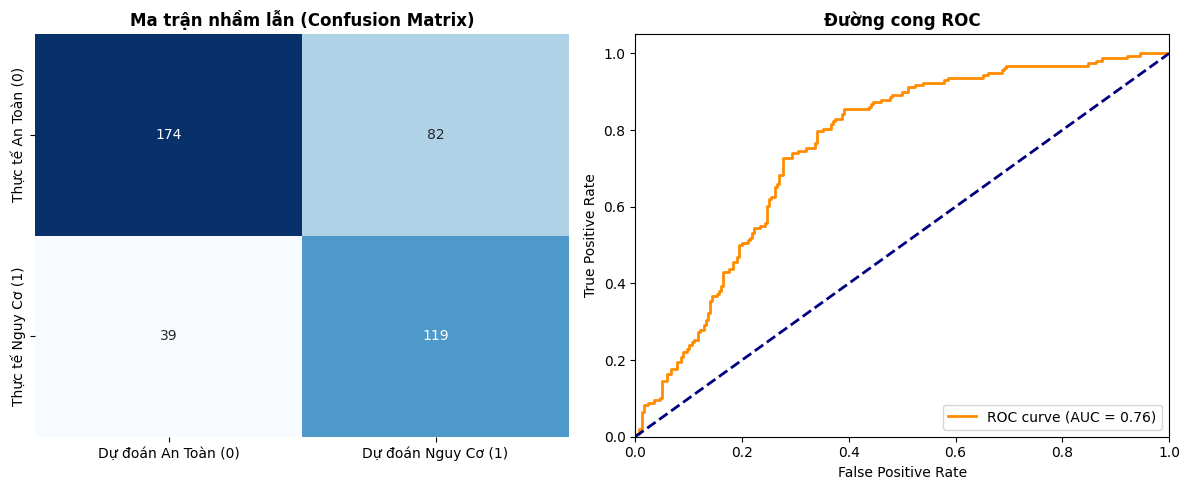


[THÀNH CÔNG] Đã lưu mô hình thành 'model_logistic_regression.pkl' và 'scaler.pkl'


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
import joblib

# 1. ĐỌC DỮ LIỆU SẠCH
df = pd.read_csv(
    r"\Data\vietnam_health_cleaned_ml.csv"
)

# 2. CHIA TÁCH FEATURE (X) VÀ TARGET (y)
X = df.drop("Target_Risk", axis=1)
y = df["Target_Risk"]

# 3. TRAIN/TEST SPLIT (80% Train, 20% Test)
# stratify=y giúp giữ nguyên tỷ lệ 62:38 ở cả 2 tập Train và Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Kích thước tập Train: {X_train.shape}")
print(f"Kích thước tập Test: {X_test.shape}")

# 4. CHUẨN HÓA DỮ LIỆU (StandardScaler)
# Logistic Regression rất nhạy cảm với scale của dữ liệu
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Lưu lại Scaler để sau này dùng cho Giao diện Web (rất quan trọng)
joblib.dump(scaler, r"Model\scaler.pkl")

# 5. KHỞI TẠO VÀ HUẤN LUYỆN MÔ HÌNH LOGISTIC REGRESSION
# class_weight='balanced' chính là chìa khóa để giải quyết độ lệch (Imbalance Data)
log_reg = LogisticRegression(class_weight="balanced", random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

# 6. DỰ ĐOÁN TRÊN TẬP TEST
y_pred = log_reg.predict(X_test_scaled)
y_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1]  # Xác suất thuộc Class 1

# 7. ĐÁNH GIÁ MÔ HÌNH (EVALUATION)
print("\n--- BÁO CÁO ĐÁNH GIÁ MÔ HÌNH LOGISTIC REGRESSION ---")
print(classification_report(y_test, y_pred))

auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"Chỉ số ROC-AUC: {auc_score:.4f}")

# Vẽ Ma trận nhầm lẫn (Confusion Matrix)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Dự đoán An Toàn (0)", "Dự đoán Nguy Cơ (1)"],
    yticklabels=["Thực tế An Toàn (0)", "Thực tế Nguy Cơ (1)"],
)
plt.title("Ma trận nhầm lẫn (Confusion Matrix)", fontweight="bold")

# Vẽ đường cong ROC
plt.subplot(1, 2, 2)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {auc_score:.2f})")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Đường cong ROC", fontweight="bold")
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

# 8. LƯU MÔ HÌNH (Export Model)
joblib.dump(
    log_reg,
    r"\Model\model_logistic_regression.pkl",
)
print(
    "\n[THÀNH CÔNG] Đã lưu mô hình thành 'Model\\model_logistic_regression.pkl' và 'Model\\scaler.pkl'"
)


# HUẤN LUYỆN RANDOM FOREST


--- BÁO CÁO ĐÁNH GIÁ MÔ HÌNH RANDOM FOREST ---
              precision    recall  f1-score   support

           0       0.76      0.79      0.78       256
           1       0.64      0.60      0.62       158

    accuracy                           0.72       414
   macro avg       0.70      0.70      0.70       414
weighted avg       0.72      0.72      0.72       414

Chỉ số ROC-AUC: 0.7916


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_19276\2883921250.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


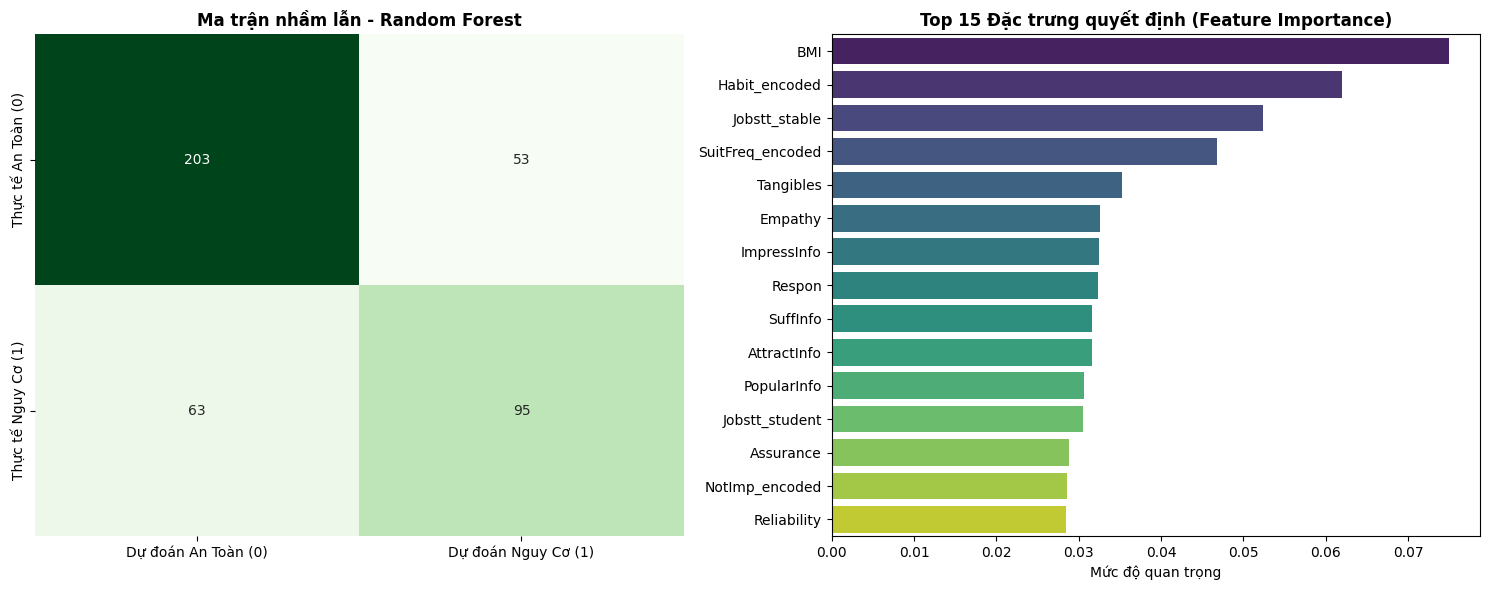


[THÀNH CÔNG] Đã lưu mô hình thành 'model_random_forest.pkl'


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
import joblib

# 1. ĐỌC DỮ LIỆU SẠCH
df = pd.read_csv(
    r"\Data\vietnam_health_cleaned_ml.csv"
)

# 2. CHIA TÁCH FEATURE (X) VÀ TARGET (y)
X = df.drop("Target_Risk", axis=1)
y = df["Target_Risk"]

# 3. TRAIN/TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. CHUẨN HÓA DỮ LIỆU (Dùng lại cấu trúc y hệt)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. KHỞI TẠO VÀ HUẤN LUYỆN RANDOM FOREST
# 'balanced_subsample' giúp cân bằng trọng số cho từng cây trong rừng
rf_model = RandomForestClassifier(
    n_estimators=200, max_depth=10, class_weight="balanced_subsample", random_state=42
)
rf_model.fit(X_train_scaled, y_train)

# 6. DỰ ĐOÁN
y_pred_rf = rf_model.predict(X_test_scaled)
y_pred_proba_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

# 7. ĐÁNH GIÁ MÔ HÌNH
print("\n--- BÁO CÁO ĐÁNH GIÁ MÔ HÌNH RANDOM FOREST ---")
print(classification_report(y_test, y_pred_rf))

auc_score_rf = roc_auc_score(y_test, y_pred_proba_rf)
print(f"Chỉ số ROC-AUC: {auc_score_rf:.4f}")

# 8. VẼ BIỂU ĐỒ ĐÁNH GIÁ VÀ ĐẶC TRƯNG QUAN TRỌNG (FEATURE IMPORTANCE)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Ma trận nhầm lẫn
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    cbar=False,
    ax=axes[0],
    xticklabels=["Dự đoán An Toàn (0)", "Dự đoán Nguy Cơ (1)"],
    yticklabels=["Thực tế An Toàn (0)", "Thực tế Nguy Cơ (1)"],
)
axes[0].set_title("Ma trận nhầm lẫn - Random Forest", fontweight="bold")

# Feature Importance (Lấy Top 15 biến quan trọng nhất)
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1][:15]  # Top 15
features = X.columns

sns.barplot(
    x=importances[indices],
    y=[features[i] for i in indices],
    ax=axes[1],
    palette="viridis",
)
axes[1].set_title("Top 15 Đặc trưng quyết định (Feature Importance)", fontweight="bold")
axes[1].set_xlabel("Mức độ quan trọng")

plt.tight_layout()
plt.show()

# 9. LƯU MÔ HÌNH
joblib.dump(
    rf_model,
    r"\Model\model_random_forest.pkl",
)
print("\n[THÀNH CÔNG] Đã lưu mô hình thành 'Model\model_random_forest.pkl'")


# HUẤN LUYỆN XGBOOST

c:\Users\ADMIN\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\core.py:158: UserWarning: [15:01:27] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-06abd128ca6c1688d-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



--- BÁO CÁO ĐÁNH GIÁ MÔ HÌNH XGBOOST ---
              precision    recall  f1-score   support

           0       0.77      0.71      0.74       256
           1       0.59      0.65      0.62       158

    accuracy                           0.69       414
   macro avg       0.68      0.68      0.68       414
weighted avg       0.70      0.69      0.69       414

Chỉ số ROC-AUC: 0.7496


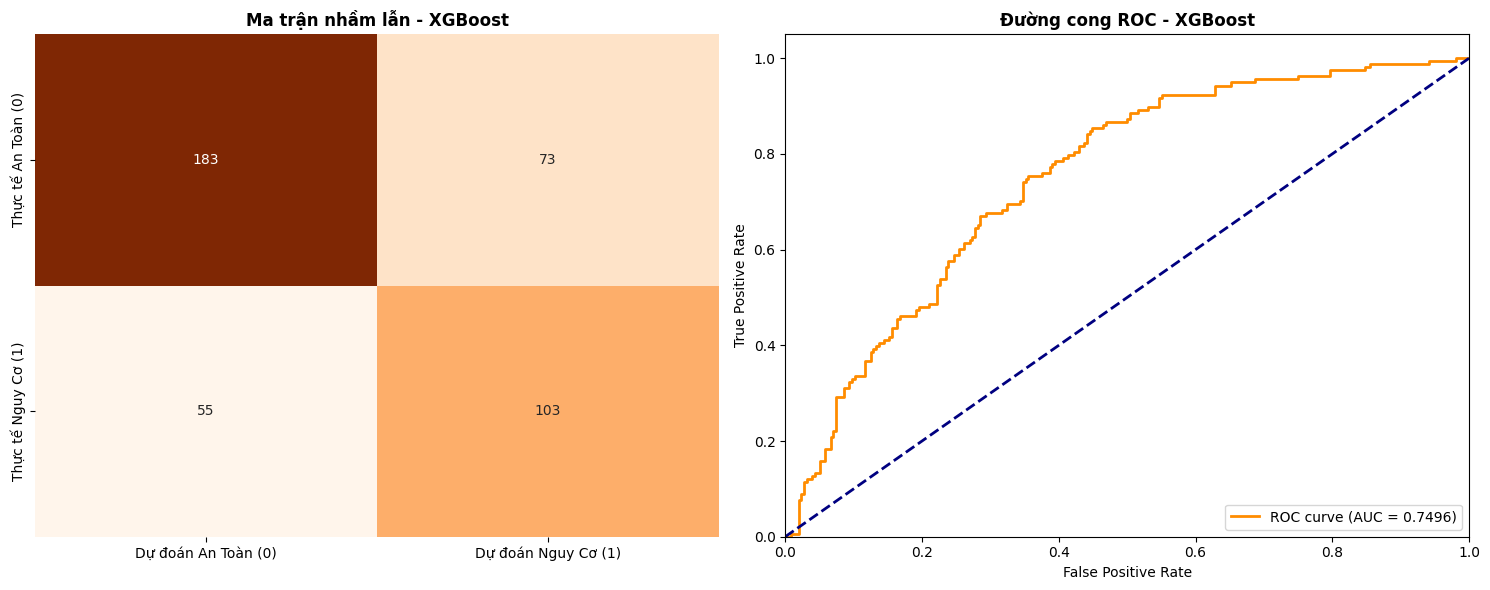


[THÀNH CÔNG] Đã lưu mô hình thành 'model_xgboost.pkl'


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
import joblib

# 1. ĐỌC DỮ LIỆU SẠCH
df = pd.read_csv(
    r"\Data\vietnam_health_cleaned_ml.csv"
)

# 2. CHIA TÁCH FEATURE (X) VÀ TARGET (y)
X = df.drop("Target_Risk", axis=1)
y = df["Target_Risk"]

# 3. TRAIN/TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. CHUẨN HÓA DỮ LIỆU
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. KHỞI TẠO VÀ HUẤN LUYỆN XGBOOST
# Tính toán tỷ lệ class_weight cho XGBoost (scale_pos_weight = số lượng class 0 / số lượng class 1)
ratio = float(np.sum(y_train == 0)) / np.sum(y_train == 1)

# max_depth=6 và learning_rate=0.05 giúp mô hình học chậm lại, chống overfitting
xgb_model = xgb.XGBClassifier(
    scale_pos_weight=ratio,
    learning_rate=0.05,
    max_depth=6,
    n_estimators=200,
    random_state=42,
    use_label_encoder=False,
    eval_metric="logloss",
)
xgb_model.fit(X_train_scaled, y_train)

# 6. DỰ ĐOÁN
y_pred_xgb = xgb_model.predict(X_test_scaled)
y_pred_proba_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]

# 7. ĐÁNH GIÁ MÔ HÌNH
print("\n--- BÁO CÁO ĐÁNH GIÁ MÔ HÌNH XGBOOST ---")
print(classification_report(y_test, y_pred_xgb))

auc_score_xgb = roc_auc_score(y_test, y_pred_proba_xgb)
print(f"Chỉ số ROC-AUC: {auc_score_xgb:.4f}")

# 8. VẼ BIỂU ĐỒ ĐÁNH GIÁ
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Ma trận nhầm lẫn
cm = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Oranges",
    cbar=False,
    ax=axes[0],
    xticklabels=["Dự đoán An Toàn (0)", "Dự đoán Nguy Cơ (1)"],
    yticklabels=["Thực tế An Toàn (0)", "Thực tế Nguy Cơ (1)"],
)
axes[0].set_title("Ma trận nhầm lẫn - XGBoost", fontweight="bold")

# Đường cong ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_xgb)
axes[1].plot(
    fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {auc_score_xgb:.4f})"
)
axes[1].plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("Đường cong ROC - XGBoost", fontweight="bold")
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

# 9. LƯU MÔ HÌNH
joblib.dump(
    xgb_model, r"\Model\model_xgboost.pkl"
)
print("\n[THÀNH CÔNG] Đã lưu mô hình thành 'Model\\model_xgboost.pkl'")


# HUẤN LUYỆN LIGHTGBM

[LightGBM] [Info] Number of positive: 633, number of negative: 1021
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000377 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 436
[LightGBM] [Info] Number of data points in the train set: 1654, number of used features: 43
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

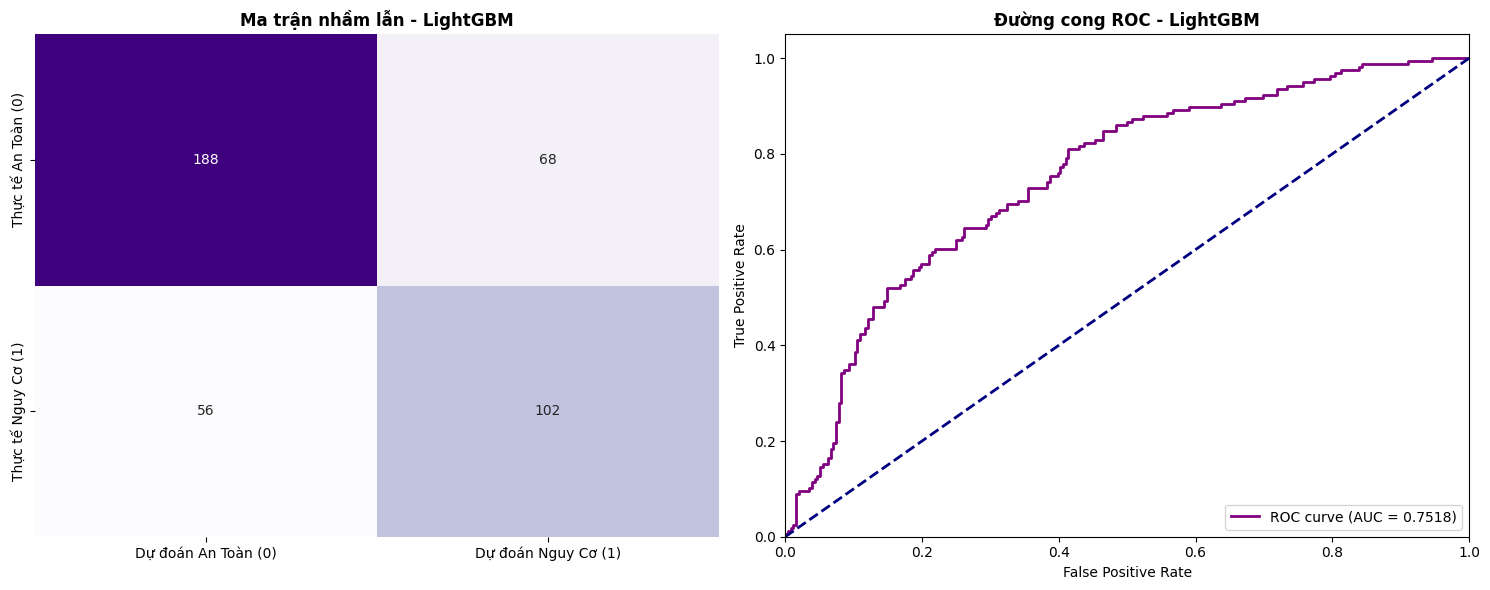


[THÀNH CÔNG] Đã lưu mô hình thành 'model_lightgbm.pkl'


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import lightgbm as lgb
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
import joblib

# 1. ĐỌC DỮ LIỆU SẠCH
df = pd.read_csv(
    r"\Data\vietnam_health_cleaned_ml.csv"
)

# 2. CHIA TÁCH FEATURE (X) VÀ TARGET (y)
X = df.drop("Target_Risk", axis=1)
y = df["Target_Risk"]

# 3. TRAIN/TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. CHUẨN HÓA DỮ LIỆU
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. KHỞI TẠO VÀ HUẤN LUYỆN LIGHTGBM
# class_weight='balanced' tích hợp sẵn giúp LightGBM xử lý data lệch chuẩn xác
lgb_model = lgb.LGBMClassifier(
    class_weight="balanced",
    n_estimators=200,
    max_depth=8,
    learning_rate=0.05,
    random_state=42,
)
lgb_model.fit(X_train_scaled, y_train)

# 6. DỰ ĐOÁN
y_pred_lgb = lgb_model.predict(X_test_scaled)
y_pred_proba_lgb = lgb_model.predict_proba(X_test_scaled)[:, 1]

# 7. ĐÁNH GIÁ MÔ HÌNH
print("\n--- BÁO CÁO ĐÁNH GIÁ MÔ HÌNH LIGHTGBM ---")
print(classification_report(y_test, y_pred_lgb))

auc_score_lgb = roc_auc_score(y_test, y_pred_proba_lgb)
print(f"Chỉ số ROC-AUC: {auc_score_lgb:.4f}")

# 8. VẼ BIỂU ĐỒ ĐÁNH GIÁ
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Ma trận nhầm lẫn
cm = confusion_matrix(y_test, y_pred_lgb)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Purples",
    cbar=False,
    ax=axes[0],
    xticklabels=["Dự đoán An Toàn (0)", "Dự đoán Nguy Cơ (1)"],
    yticklabels=["Thực tế An Toàn (0)", "Thực tế Nguy Cơ (1)"],
)
axes[0].set_title("Ma trận nhầm lẫn - LightGBM", fontweight="bold")

# Đường cong ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_lgb)
axes[1].plot(
    fpr, tpr, color="purple", lw=2, label=f"ROC curve (AUC = {auc_score_lgb:.4f})"
)
axes[1].plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("Đường cong ROC - LightGBM", fontweight="bold")
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

# 9. LƯU MÔ HÌNH
joblib.dump(
    lgb_model, r"\Model\model_lightgbm.pkl"
)
print("\n[THÀNH CÔNG] Đã lưu mô hình thành 'Model\\model_lightgbm.pkl'")


# HUẤN LUYỆN RANDOM FOREST (tối ưu hoá tham số)

Đang tiến hành tìm kiếm siêu tham số tối ưu (Vui lòng đợi 1-2 phút)...

[XONG] Bộ tham số tối ưu nhất: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 15}

--- BÁO CÁO RANDOM FOREST (ĐÃ TỐI ƯU & NGƯỠNG 0.4) ---
              precision    recall  f1-score   support

           0       0.87      0.64      0.74       256
           1       0.59      0.84      0.69       158

    accuracy                           0.72       414
   macro avg       0.73      0.74      0.72       414
weighted avg       0.76      0.72      0.72       414

Chỉ số ROC-AUC MỚI: 0.7926


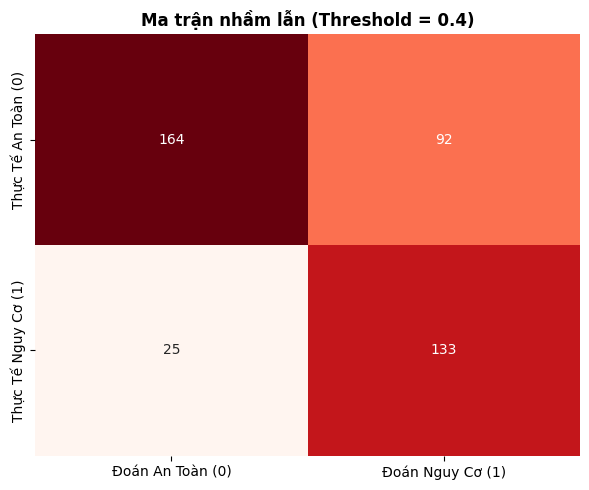

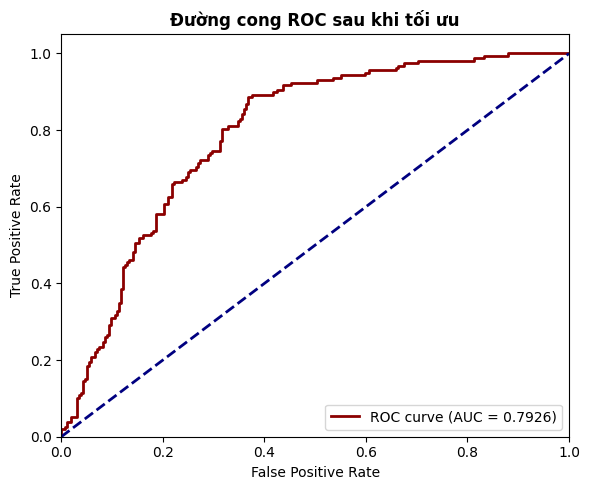


[THÀNH CÔNG] Đã lưu mô hình tối ưu thành 'Modeest_model_random_forest.pkl'


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import joblib

# 1. ĐỌC VÀ CHUẨN BỊ DỮ LIỆU
df = pd.read_csv(
    r"\Data\vietnam_health_cleaned_ml.csv"
)
X = df.drop("Target_Risk", axis=1)
y = df["Target_Risk"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. THIẾT LẬP LƯỚI THAM SỐ ĐỂ TÌM KIẾM (HYPERPARAMETER GRID)
param_dist = {
    "n_estimators": [100, 200, 300, 400, 500],
    "max_depth": [5, 8, 10, 15, 20, None],
    "min_samples_split": [2, 5, 10, 15],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": ["sqrt", "log2", None],
}

# Khởi tạo mô hình cơ sở
rf_base = RandomForestClassifier(class_weight="balanced_subsample", random_state=42)

# Chạy tìm kiếm ngẫu nhiên (Tìm kiếm bộ tham số tốt nhất trong 50 cấu hình)
print("Đang tiến hành tìm kiếm siêu tham số tối ưu (Vui lòng đợi 1-2 phút)...")
random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=50,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    random_state=42,
)
random_search.fit(X_train_scaled, y_train)

# In ra bộ tham số xịn nhất đã tìm được
best_rf = random_search.best_estimator_
print(f"\n[XONG] Bộ tham số tối ưu nhất: {random_search.best_params_}")

# 3. DỰ ĐOÁN VỚI XÁC SUẤT (PROBABILITY)
y_pred_proba_best = best_rf.predict_proba(X_test_scaled)[:, 1]

# 4. ĐIỀU CHỈNH NGƯỠNG QUYẾT ĐỊNH (THRESHOLD MOVING)
# Thay vì lấy mốc 0.5, ta hạ xuống 0.4 để ưu tiên bắt Nhóm Nguy Cơ (Tăng Recall)
custom_threshold = 0.4
y_pred_custom = (y_pred_proba_best >= custom_threshold).astype(int)

# 5. ĐÁNH GIÁ MÔ HÌNH SAU KHI TỐI ƯU
print(f"\n--- BÁO CÁO RANDOM FOREST (ĐÃ TỐI ƯU & NGƯỠNG {custom_threshold}) ---")
print(classification_report(y_test, y_pred_custom))

auc_best = roc_auc_score(y_test, y_pred_proba_best)
print(f"Chỉ số ROC-AUC MỚI: {auc_best:.4f}")

# Vẽ Ma trận nhầm lẫn để so sánh
plt.figure(figsize=(6, 5))
cm_best = confusion_matrix(y_test, y_pred_custom)
sns.heatmap(
    cm_best,
    annot=True,
    fmt="d",
    cmap="Reds",
    cbar=False,
    xticklabels=["Đoán An Toàn (0)", "Đoán Nguy Cơ (1)"],
    yticklabels=["Thực Tế An Toàn (0)", "Thực Tế Nguy Cơ (1)"],
)
plt.title(f"Ma trận nhầm lẫn (Threshold = {custom_threshold})", fontweight="bold")
plt.tight_layout()
plt.show()

# Đường cong ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_best)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color="darkred", lw=2, label=f"ROC curve (AUC = {auc_best:.4f})")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Đường cong ROC sau khi tối ưu", fontweight="bold")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# 6. LƯU LẠI MÔ HÌNH HOÀN HẢO NHẤT ĐỂ LÀM WEB
joblib.dump(
    best_rf,
    r"\Model\best_model_random_forest.pkl",
)
joblib.dump(scaler, r"\Model\best_scaler.pkl")
print("\n[THÀNH CÔNG] Đã lưu mô hình tối ưu thành 'Model\best_model_random_forest.pkl'")